In [ ]:
import cospar as cs
import pandas as pd
import os
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import mosaiclineage as mosaic
import mosaiclineage.help_functions as hf
import mosaiclineage.plot_scripts as mosaic_pl
import mosaiclineage.DARLIN as mosaic_dar
import warnings
warnings.filterwarnings("ignore")

## setting cospar
cs.logging.print_version()
cs.settings.verbosity = 0
cs.settings.set_figure_params(format='pdf', figsize=[4,3.5], dpi=75, fontsize=14, pointsize=2)

%matplotlib inline

## notebook specific parameters
target_sample = 'TA'
read_cutoff = 3        # Read cutoff
min_clone_size = 2     # Clone size cutoff
max_rep_N = 0          # Mouse replicate number cutoff
frequency_cutoff = 0.1 # Allele probability cutoff
BC_complexity = 4      # Barcode complexity cutoff
norm_method = ''       # choices: '', '_CloneNumNorm', '_CloneSizeCutOff
save_data_des = f'_freqCutoff{frequency_cutoff}{norm_method}'

## setup folders 
root_path = '/scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3'   # <-- change if needed
ref_dir = mosaic.settings.ref_dir
root_analysis_path = os.path.join(root_path, 'TA')
data_path = os.path.join(root_analysis_path, 'DARLIN', f'results_cutoff_override_{read_cutoff}')

if os.path.exists(root_path):
    data_analysis_path = os.path.join(root_analysis_path, 'data')   
    paper_figure_path = os.path.join(root_analysis_path, 'figure')    
    os.makedirs(data_analysis_path, exist_ok=True)
    os.makedirs(paper_figure_path, exist_ok=True)
    cs.settings.data_path = data_analysis_path
    cs.settings.figure_path = paper_figure_path

## your selected samples
sample_names = [
    "DRG-L1-TA_S23_L001",
    "DRG-L2-TA_S24_L001",
    "DRG-R1-TA_S25_L001",
    "DRG-R2-TA_S26_L001",
    "SG-L1-TA_S27_L001",
    "Heart-TA_S31_L001",
    "Liver-TA_S32_L001"
]



print("Samples:", sample_names)
print("Data path:", data_path)


Running cospar 0.3.3 (python 3.8.20) on 2025-10-09 11:24.
Samples: ['DRG-L1-TA_S23_L001', 'DRG-L2-TA_S24_L001', 'DRG-R1-TA_S25_L001', 'DRG-R2-TA_S26_L001', 'SG-L1-TA_S27_L001', 'Heart-TA_S31_L001', 'Liver-TA_S32_L001']
Data path: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/TA/DARLIN/results_cutoff_override_3


ERROR: XMLRPC request failed [code: -32500]
RuntimeError: PyPI no longer supports 'pip search' (or XML-RPC search). Please use https://pypi.org/search (via a browser) instead. See https://warehouse.pypa.io/api-reference/xml-rpc.html#deprecated-methods for more information.


In [55]:
def apply_frequency_and_complexity_cutoff_to_get_HQ_alleles(df_merge, BC_complexity, frequency_cutoff):
    # Generate single-allele CARLIN table
    df_sc_CARLIN = hf.generate_sc_CARLIN_from_CARLIN_output(df_merge)
    
    # Count number of mutations per allele
    df_sc_CARLIN['mutation_N'] = df_sc_CARLIN['allele'].apply(lambda x: len(x.split(',')))
    
    # Remove "locus_" prefix if present
    df_sc_CARLIN['allele'] = df_sc_CARLIN['allele'].apply(lambda x: x[6:] if x.startswith('locus_') else x)
    
    # Calculate total insertion length for each allele
    ins_per_allele, del_per_allele = hf.mutations_length_per_allele_ins_del(df_sc_CARLIN)
    df_sc_CARLIN['insertion_length'] = [np.sum(x) for x in ins_per_allele]
    
    # Filter for high-quality alleles based on frequency and complexity cutoffs
    df_sc_CARLIN_HQ_raw = mosaic_dar.filter_high_quality_single_alleles(
        df_sc_CARLIN,
        normalized_count_cutoff=frequency_cutoff,
        sample_count_cutoff=max_rep_N
    )
    
    # Keep alleles that meet the barcode complexity requirement
    df_sc_CARLIN_HQ = df_sc_CARLIN_HQ_raw[
        (df_sc_CARLIN_HQ_raw['mutation_N'] + df_sc_CARLIN_HQ_raw['insertion_length']) >= BC_complexity
    ]
    
    return df_sc_CARLIN_HQ


def pvalue_estimation(df_tmp, key_1, key_2):
    from scipy.stats import ttest_ind
    var_list = list(df_tmp[key_1].unique())
    name_list = []
    pvalue_list = []
    
    for i in range(len(var_list)):
        for j in range(i + 1, len(var_list)):
            test_data_0 = df_tmp[df_tmp[key_1] == var_list[i]][key_2].values
            test_data_1 = df_tmp[df_tmp[key_1] == var_list[j]][key_2].values
            stat, pvalue = ttest_ind(test_data_0, test_data_1)
            name_list.append((var_list[i], var_list[j]))
            pvalue_list.append(pvalue)
            
    return pd.DataFrame({'name': name_list, 'pvalue': pvalue_list})


# === No renaming needed for your CA samples ===
def rename_LF(x):
    return x


In [56]:
#Config parameters

In [57]:
# === Metadata setup for your TA samples ===

mouse_list = ['TA']
stage_order = ['Adult']

map_mouse_to_SampleList = {'TA': 'tissues'}
stage_map_new = {'Adult': 'Adult-1'}
mouse_map = {'TA': 'Adult'}
mouse_map_2 = {'TA': 'Induce at adult (TA samples)'}

# Tissue colors for your TA samples
tissue_colors = dict(zip(
    ['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'SG-L1', 'Heart', 'Liver'],
    sns.color_palette("tab10", 7).as_hex()
))

celltype_colors = {'Tissue': '#66c2a5'}

ylim_map = {'TA': 1000}
title_map = {'Adult': 'DARLIN TA Samples'}
stage_id_map = dict(zip(stage_order, np.arange(len(stage_order))))

SampleList_RAW_0 = [
    "DRG-L1-TA_S23_L001",
    "DRG-L2-TA_S24_L001",
    "DRG-R1-TA_S25_L001",
    "DRG-R2-TA_S26_L001",
    "SG-L1-TA_S27_L001",
    "Heart-TA_S31_L001",
    "Liver-TA_S32_L001"
]

SampleList_RAW_noSkull_0 = SampleList_RAW_0.copy()

print("Samples:", SampleList_RAW_0)
print("Tissue color map:", tissue_colors)
print("Stage ID map:", stage_id_map)


Samples: ['DRG-L1-TA_S23_L001', 'DRG-L2-TA_S24_L001', 'DRG-R1-TA_S25_L001', 'DRG-R2-TA_S26_L001', 'SG-L1-TA_S27_L001', 'Heart-TA_S31_L001', 'Liver-TA_S32_L001']
Tissue color map: {'DRG-L1': '#1f77b4', 'DRG-L2': '#ff7f0e', 'DRG-R1': '#2ca02c', 'DRG-R2': '#d62728', 'SG-L1': '#9467bd', 'Heart': '#8c564b', 'Liver': '#e377c2'}
Stage ID map: {'Adult': 0}


In [58]:
#Load data and save to csv file

In [59]:
locus = 'TA'

# === Load allele reference table ===
df_ref = pd.read_csv(f'{ref_dir}/reference_merged_alleles_{locus}.csv')
df_ref['invalid_alleles'] = (
    (df_ref['normalized_count'] >= frequency_cutoff) |
    (df_ref['sample_count'] > max_rep_N)
)

# === Loop over read cutoff and dataset (now TA) ===
for read_cutoff_tmp in [3]:  # Read cutoff
    for mouse in mouse_list:  # mouse_list = ['TA']
        print(mouse)

        data_path_tmp = root_path
        merge_all_path = f'{data_path_tmp}/merge_all'
        os.makedirs(merge_all_path, exist_ok=True)

        # Use all 7 TA samples
        SampleList_RAW = [
            "DRG-L1-TA_S23_L001",
            "DRG-L2-TA_S24_L001",
            "DRG-R1-TA_S25_L001",
            "DRG-R2-TA_S26_L001",
            "SG-L1-TA_S27_L001",
            "Heart-TA_S31_L001",
            "Liver-TA_S32_L001"
        ]

        # === Extract the allele table ===
        df_all = mosaic.DARLIN.extract_CARLIN_info(
            data_path_tmp,
            SampleList_RAW,
            sample_name_format='TA'  # updated naming pattern
        )

        # === Merge with reference allele frequencies ===
        df_all = df_all.merge(df_ref, on="allele", how="left")

        # === Save the merged allele data ===
        output_file = f'{merge_all_path}/df_allele_all_{mouse}_{save_data_des}.csv'
        df_all.to_csv(output_file, index=False)

        print(f"Saved: {output_file}")
        display(df_all.head(10))


TA
Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_TA__freqCutoff0.1.csv


,allele,UMI_count,sample,mouse,CB,CB_N,CARLIN,CARLIN_length,clone_size,observed_count,sample_count,normalized_count,smoothed_homoplasy,sample_id,invalid_alleles
0,24_266del,12,DRG-L1-TA_S23_L001,DRG-L1-TA_S23_L001,"ATGACGCCTTCCCT,CATACCACTCCCCT,CCTGCATGGCAAGG,C...",12,TCGCCGGAGTCGAGACGCTGACGCTATGGA,30,4073,27991.0,9.0,0.024610,1.000000,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
1,24_266del,37,DRG-L2-TA_S24_L001,DRG-L2-TA_S24_L001,"AACACTCCAATATT,AAGCGTTGACTATG,ACATGCTCGAGATG,A...",37,TCGCCGGAGTCGAGACGCTGACGCTATGGA,30,4073,27991.0,9.0,0.024610,1.000000,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
2,24_266del,733,DRG-R1-TA_S25_L001,DRG-R1-TA_S25_L001,"AAACCAGCTACGTA,AAAGTAACATTGCG,AAAGTAGCTTAGGC,A...",733,TCGCCGGAGTCGAGACGCTGACGCTATGGA,30,4073,27991.0,9.0,0.024610,1.000000,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
3,24_266del,1482,DRG-R2-TA_S26_L001,DRG-R2-TA_S26_L001,"AAAACTATTCATTC,AAAACTCAGGGGTT,AAACAATGTGGGAC,A...",1482,TCGCCGGAGTCGAGACGCTGACGCTATGGA,30,4073,27991.0,9.0,0.024610,1.000000,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
4,24_266del,820,SG-L1-TA_S27_L001,SG-L1-TA_S27_L001,"AAAAAGAAATTCGT,AAAAGCCTCAGCGT,AAAAGTTGTAAACA,A...",820,TCGCCGGAGTCGAGACGCTGACGCTATGGA,30,4073,27991.0,9.0,0.024610,1.000000,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
5,24_266del,818,Heart-TA_S31_L001,Heart-TA_S31_L001,"AAAATATGCCTAAG,AAACAAACTCTATT,AAAGGACTCGTACT,A...",818,TCGCCGGAGTCGAGACGCTGACGCTATGGA,30,4073,27991.0,9.0,0.024610,1.000000,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
6,24_266del,171,Liver-TA_S32_L001,Liver-TA_S32_L001,"AAACATGCATAGCT,AAACCTGCCATGTT,AAACGACGGGTCTA,A...",171,TCGCCGGAGTCGAGACGCTGACGCTATGGA,30,4073,27991.0,9.0,0.024610,1.000000,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
7,20_268del,6,DRG-L1-TA_S23_L001,DRG-L1-TA_S23_L001,"ATCGGACTCAGCGG,CAGAGTTGATTAGG,CTTATCCGTTAAAG,G...",6,TCGCCGGAGTCGAGACGCTATGGA,24,264,1799.0,9.0,0.001582,0.999978,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
8,20_268del,1,DRG-L2-TA_S24_L001,DRG-L2-TA_S24_L001,CACGTGGCAATCAA,1,TCGCCGGAGTCGAGACGCTATGGA,24,264,1799.0,9.0,0.001582,0.999978,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True
9,20_268del,49,DRG-R1-TA_S25_L001,DRG-R1-TA_S25_L001,"AAGCGCGAATCTGG,AAGGTCTGTTTAGG,AATATTCTACACCC,A...",49,TCGCCGGAGTCGAGACGCTATGGA,24,264,1799.0,9.0,0.001582,0.999978,"['LL583', 'LL719', 'LL638', 'LL584', 'LL837', ...",True


In [ ]:
for mouse in mouse_list:  # mouse_list = ['TA']
    for BC_complexity_tmp in [2, 4, 6]:
        print(mouse)

        # 
        df_merge = pd.read_csv(
            f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}.csv'
        )

        # Rename sample names (your rename_LF function just returns the same name)
        df_merge['sample'] = df_merge['sample'].apply(rename_LF)

        # Apply filters for high-quality alleles
        df_sc_CARLIN_HQ = apply_frequency_and_complexity_cutoff_to_get_HQ_alleles(
            df_merge, BC_complexity_tmp, frequency_cutoff
        )

        # Save the filtered high-quality allele table
        output_file = (
            f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_'
            f'HQ_BCcomplex{BC_complexity_tmp}_freq{frequency_cutoff}.csv'
        )
        df_sc_CARLIN_HQ.to_csv(output_file, index=False)

        print(f"Saved: {output_file}")


TA
Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_TA__freqCutoff0.1_HQ_BCcomplex2_freq0.1.csv
TA
Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_TA__freqCutoff0.1_HQ_BCcomplex4_freq0.1.csv
TA
Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_TA__freqCutoff0.1_HQ_BCcomplex6_freq0.1.csv


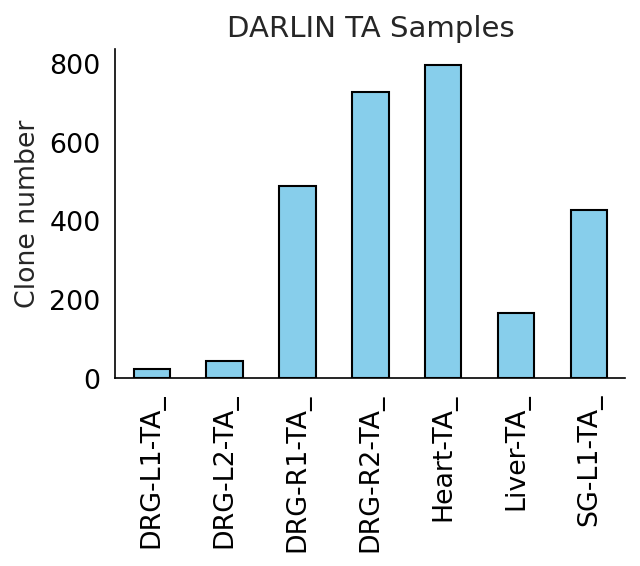

Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/TA/figure/clone_number_TA.pdf


In [61]:
for mouse in mouse_list:  # mouse_list = ['TA']
    # Load the filtered high-quality allele table
    df_sc_CARLIN_HQ = pd.read_csv(
        f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv'
    )

    # Create bar plot: clone number per sample
    fig, ax = plt.subplots(figsize=(4.5, 4))
    df_sc_CARLIN_HQ.groupby('sample').agg({'allele': lambda x: len(set(x))}).plot(
        kind='bar', ax=ax, color='skyblue', edgecolor='black'
    )

    plt.xlabel('')
    plt.ylabel('Clone number')
    ax.get_legend().remove()
    plt.title(title_map['Adult'])   # equivalent to mouse_map[mouse] in your case
    plt.tight_layout()

    # Save figure
    plt.savefig(f'{paper_figure_path}/clone_number_{mouse}.pdf')
    plt.show()

    print(f"Saved: {paper_figure_path}/clone_number_{mouse}.pdf")


------TA-----


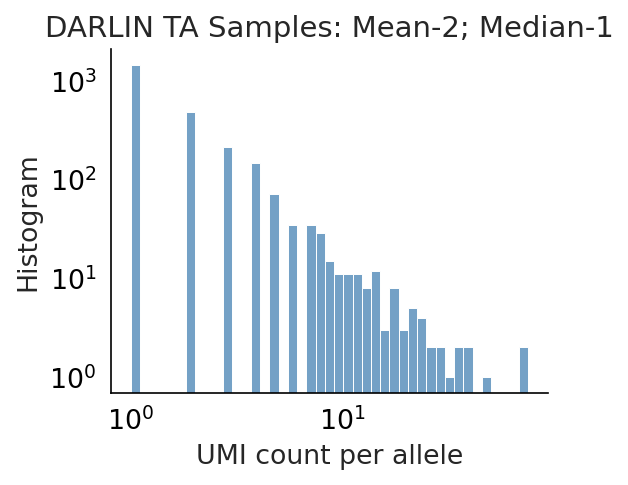

mean: 2.4861325115562405
median: 1.0


In [62]:
for mouse in mouse_list:  # mouse_list = ['TA']
    print(f'------{mouse}-----')

    # Load the high-quality allele file
    df_sc_CARLIN_HQ = pd.read_csv(
        f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv'
    )

    # === Compute UMI count per allele ===
    fig, ax = plt.subplots(figsize=(4, 3.5))
    df_plot = df_sc_CARLIN_HQ.groupby('allele').agg(
        count=('RNA_id', lambda x: len(set(x)))
    )

    # === Plot histogram ===
    sns.histplot(data=df_plot, x='count', log_scale=True, color='steelblue', edgecolor=None)
    plt.yscale('log')

    # === Compute and display mean/median ===
    X_mean = df_plot['count'].mean()
    X_median = df_plot['count'].median()

    plt.title(f'DARLIN TA Samples: Mean-{X_mean:.0f}; Median-{X_median:.0f}')
    plt.xlabel('UMI count per allele')
    plt.ylabel('Histogram')
    plt.tight_layout()

    # === Save figure ===
    plt.savefig(f'{paper_figure_path}/clone_size_distribution_{mouse}.pdf')
    plt.show()

    print('mean:', X_mean)
    print('median:', X_median)


------ TA ------


100%|██████████| 6454/6454 [00:00<00:00, 675315.90it/s]


🧾 After cleaning suffixes:
['DRG-R1-TA' 'DRG-R2-TA' 'SG-L1-TA' 'Heart-TA' 'Liver-TA' 'DRG-L2-TA'
 'DRG-L1-TA']

Expected mapping keys: ['DRG-L1-TA', 'DRG-L2-TA', 'DRG-R1-TA', 'DRG-R2-TA', 'SG-L1-TA', 'Heart-TA', 'Liver-TA']
Expected short_names: ['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'SG-L1', 'Heart', 'Liver']
Using fates: ['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'SG-L1', 'Heart', 'Liver']


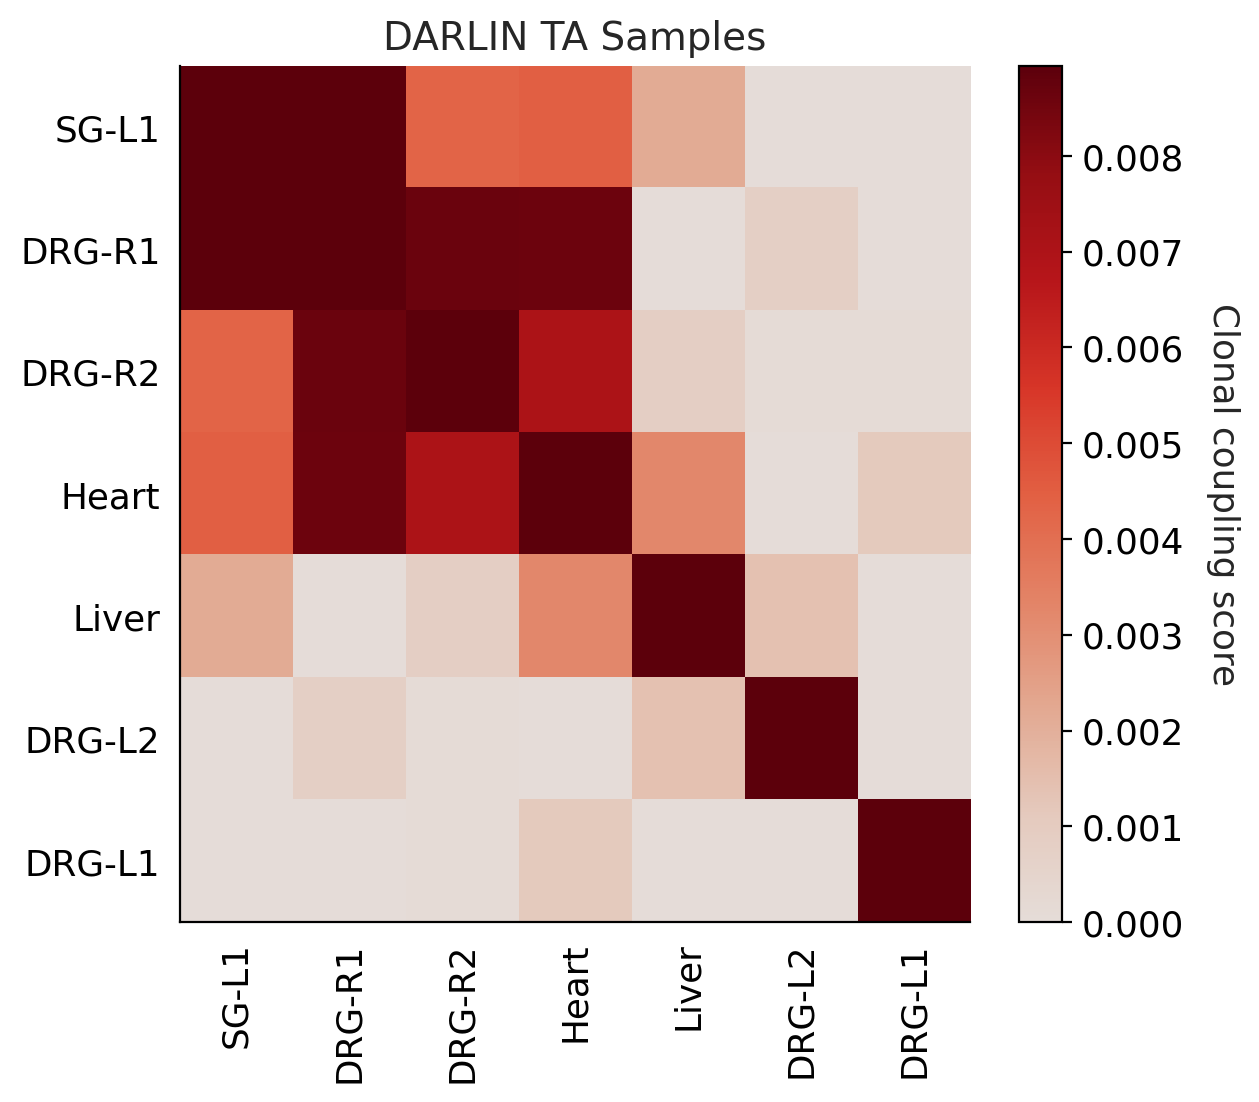

Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/TA/figure/fate_coupling_TA.pdf


In [ ]:
for mouse in mouse_list:  # e.g. mouse_list = ['TA']
    print(f"------ {mouse} ------")

    # === Use all TA samples ===
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_0]

    #  Short names - simplified and robust
    short_names = [
        x.replace("DRG-L1-TA", "DRG-L1")
         .replace("DRG-L2-TA", "DRG-L2")
         .replace("DRG-R1-TA", "DRG-R1")
         .replace("DRG-R2-TA", "DRG-R2")
         .replace("SG-L1-TA", "SG-L1")
         .replace("Heart-TA", "Heart")
         .replace("Liver-TA", "Liver")
        for x in SampleList_RAW
    ]

    # === Load high-quality allele data ===
    df_sc_CARLIN_HQ = pd.read_csv(
        f"{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv"
    )

    # === Generate clone-by-allele matrix ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key="allele"
    )

    # === Configure figure settings ===
    cs.settings.set_figure_params(figsize=(6, 5.5))

    # === Clean and standardize state_info ===
    adata_orig.obs["state_info"] = adata_orig.obs["state_info"].astype(str)
    adata_orig.obs["state_info"] = adata_orig.obs["state_info"].str.replace(r"_S\d+_L\d+", "", regex=True)
    adata_orig.obs["state_info"] = adata_orig.obs["state_info"].str.replace(r"_$", "", regex=True)

    # --- Debug inspection (optional) ---
    print("\n🧾 After cleaning suffixes:")
    print(adata_orig.obs["state_info"].unique()[:20])
    print("\nExpected mapping keys:", SampleList_RAW)
    print("Expected short_names:", short_names)

    # === Rename long sample names → short names ===
    adata_orig.obs["state_info"] = adata_orig.obs["state_info"].map(
        dict(zip(SampleList_RAW, short_names))
    )

    # === Convert to string (avoid float issues) ===
    adata_orig.obs["time_info"] = ["TA" in str(x) for x in adata_orig.obs["state_info"]]

    # === Filter valid fates present in data ===
    valid_fates = [f for f in short_names if f in adata_orig.obs["state_info"].unique()]
    print("Using fates:", valid_fates)

    if len(valid_fates) == 0:
        raise ValueError(" No valid fates found — check sample name matching before running fate_coupling.")

    # === Compute fate coupling ===
    cs.tl.fate_coupling(
        adata_orig,
        selected_fates=valid_fates,
        source="X_clone",
        normalize=True
    )

    # === Plot fate coupling heatmap ===
    cs.pl.fate_coupling(
        adata_orig,
        source="X_clone",
        title="DARLIN TA Samples"
    )

    # === Save output ===
    plt.savefig(f"{paper_figure_path}/fate_coupling_TA.pdf")
    plt.show()
    print(f"Saved: {paper_figure_path}/fate_coupling_TA.pdf")



------ TA ------
📄 Reading: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_TA__freqCutoff0.1_HQ_BCcomplex4_freq0.1.csv


100%|██████████| 6454/6454 [00:00<00:00, 667538.91it/s]

✅ Using fates: ['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'SG-L1']


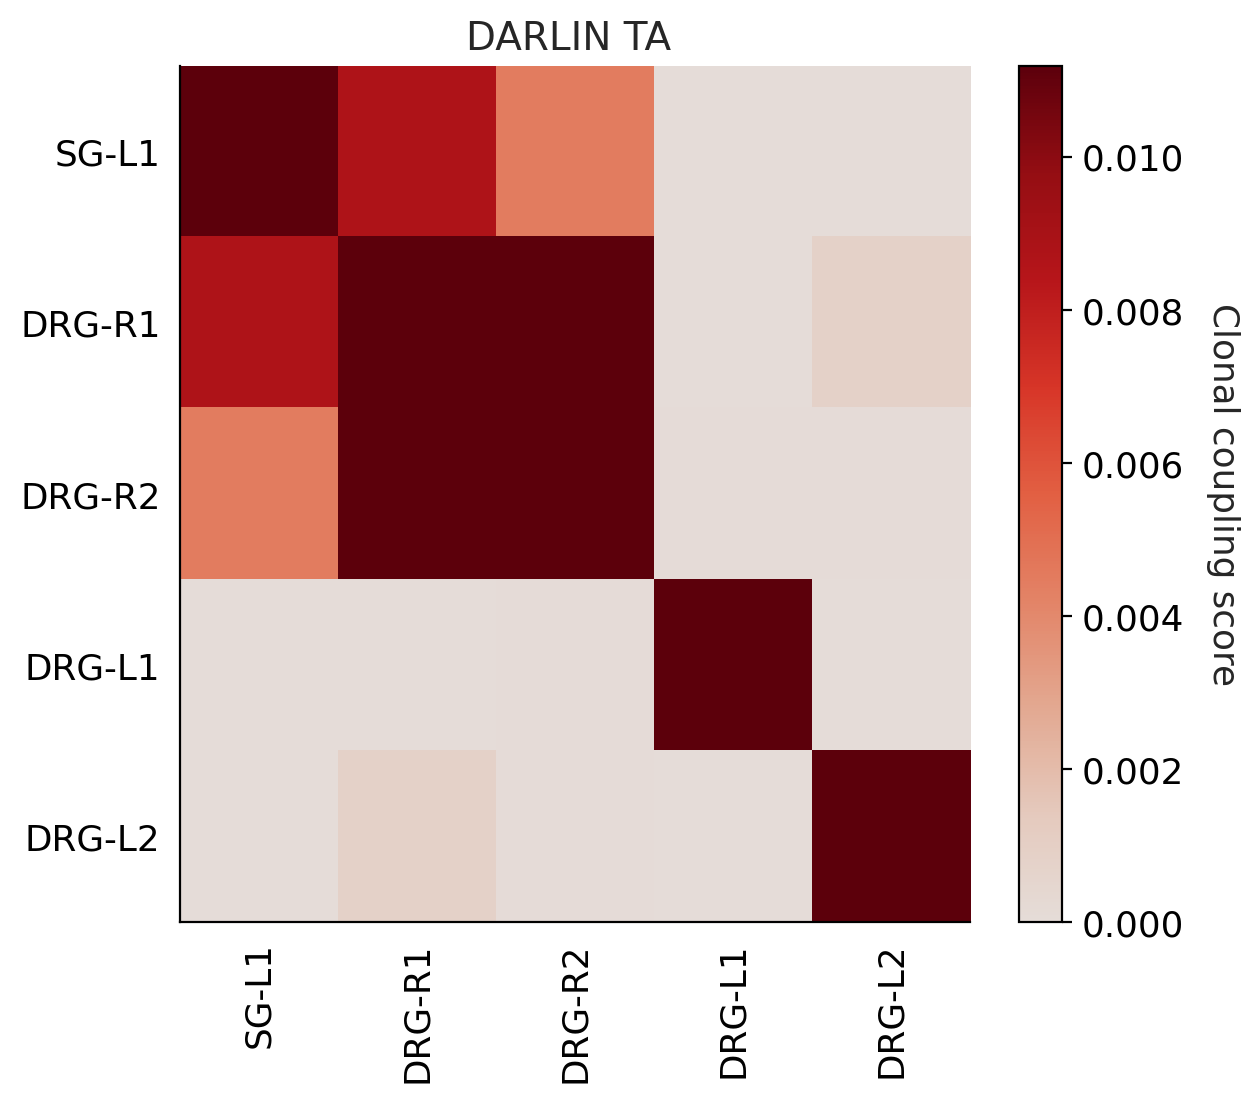

💾 Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/figure/fate_coupling_TA_.pdf


In [ ]:
# ============================================================
#   Fate coupling for TA dataset (Heart removed) - Hybrid Logic
#   Combines structure of CODE 2 + clarity of CODE 1
# ============================================================

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import cospar as cs
import mosaiclineage.help_functions as hf

# === Basic parameters ===
mouse_list = ['TA']
BC_complexity = 4
frequency_cutoff = 0.1
min_clone_size = 2
save_data_des = 'final'  # descriptor (not used in filename matching)

# === Paths ===
root_path = '/scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3'
paper_figure_path = os.path.join(root_path, 'figure')
os.makedirs(paper_figure_path, exist_ok=True)

# === Sample definitions ===
SampleList_RAW_0 = [
    'DRG-L1-TA_', 'DRG-L2-TA_', 'DRG-R1-TA_', 'DRG-R2-TA_',
    'SG-L1-TA_', 
]
# Remove Heart for this analysis
SampleList_RAW_noHeart = [x for x in SampleList_RAW_0 if 'Heart' not in x]

# === Main loop ===
for mouse in mouse_list:
    print(f"\n------ {mouse} ------")

    # Generate sample names
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_noHeart]
    short_names = [
        x.replace("DRG-L1-TA", "DRG-L1")
         .replace("DRG-L2-TA", "DRG-L2")
         .replace("DRG-R1-TA", "DRG-R1")
         .replace("DRG-R2-TA", "DRG-R2")
         .replace("SG-L1-TA", "SG-L1")
        for x in SampleList_RAW
    ]

    # === Automatically detect correct CSV file ===
    pattern = f"{root_path}/merge_all/df_allele_all_{mouse}*_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv"
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f" No matching file found for pattern: {pattern}")
    file_path = matches[0]

    print(f" Reading: {file_path}")
    df_sc_CARLIN_HQ = pd.read_csv(file_path)

    # === Generate clone matrix ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    # === Configure Cospar plotting ===
    cs.settings.set_figure_params(figsize=(6, 5.5))

    # === Clean and map sample names ===
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].astype(str)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace(r"_S\d+_L\d+", "", regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace(r"_$", "", regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].map(dict(zip(SampleList_RAW, short_names)))

    # === Remove any Heart cells just in case ===
    adata_orig = adata_orig[~adata_orig.obs['state_info'].isin(['Heart', 'Heart-TA'])].copy()

    # === Validate available fates ===
    valid_fates = [f for f in short_names if f in adata_orig.obs['state_info'].unique()]
    if len(valid_fates) == 0:
        raise ValueError(" No valid fates found — check mapping.")

    print(" Using fates:", valid_fates)

    # === Compute fate coupling ===
    cs.tl.fate_coupling(
        adata_orig,
        selected_fates=valid_fates,
        source='X_clone',
        normalize=True
    )

    # === Plot fate coupling ===
    cs.pl.fate_coupling(
        adata_orig,
        source='X_clone',
        title='DARLIN TA '
    )

    # === Save figure ===
    output_path = f"{paper_figure_path}/fate_coupling_TA_.pdf"
    plt.savefig(output_path)
    plt.show()
    print(f"💾 Saved: {output_path}")


In [65]:
#####################Removed heart###############

------ TA ------
Reading: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_TA__freqCutoff0.1_HQ_BCcomplex4_freq0.1.csv


100%|██████████| 6454/6454 [00:00<00:00, 671879.82it/s]


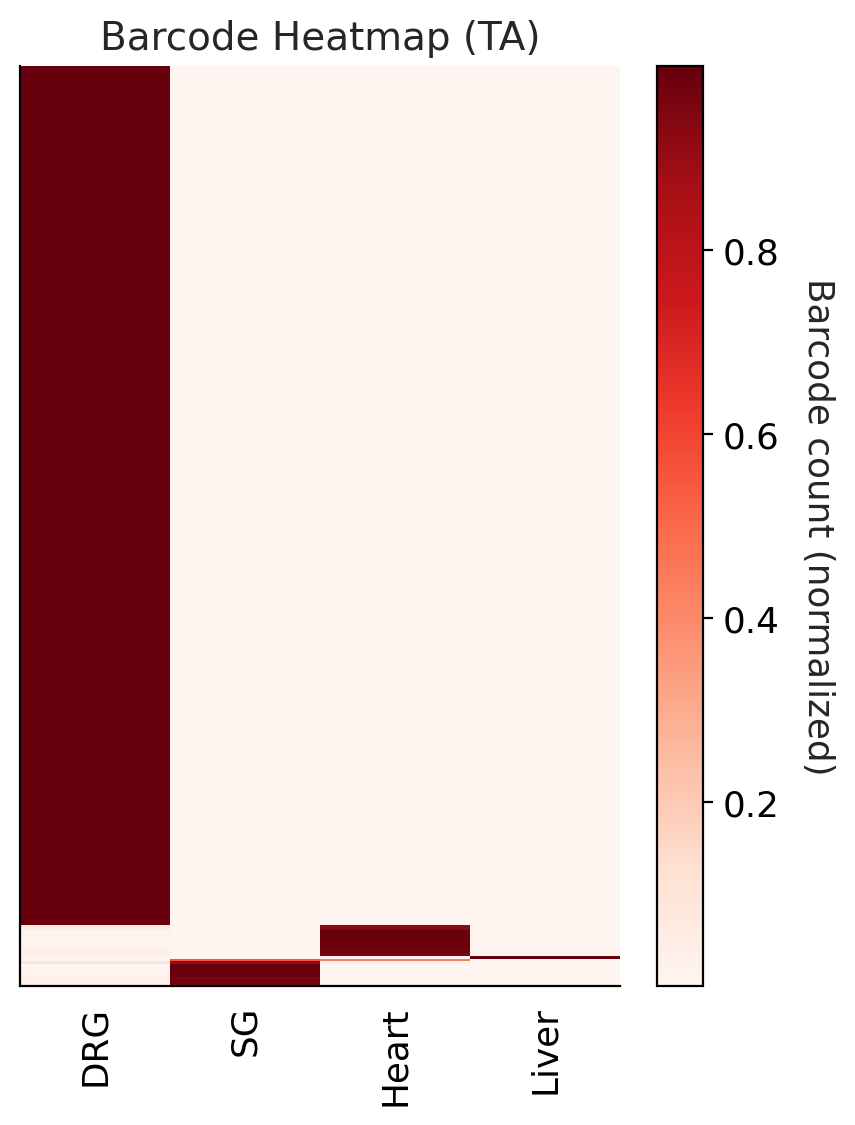

✅ Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/figure/restricted_barcode_heatmap_tissue_TA.pdf


In [ ]:
# === Restricted Barcode Heatmap for TA Dataset ===

import os
import pandas as pd
import matplotlib.pyplot as plt
import cospar as cs
import mosaiclineage.help_functions as hf
import mosaiclineage.plot_scripts as mosaic_pl

mouse_list = ['TA']
BC_complexity = 4
frequency_cutoff = 0.1
min_clone_size = 2

# === Paths ===
data_path = '/scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3'
paper_figure_path = os.path.join(data_path, 'figure')
os.makedirs(paper_figure_path, exist_ok=True)

# === Loop through mouse_list (only TA in your case) ===
for mouse in mouse_list:
    print(f"------ {mouse} ------")

    # Define sample groups for your TA dataset (with trailing underscores)
    SampleList_RAW_1 = [
        "DRG-L1-TA_", "DRG-L2-TA_", "DRG-R1-TA_", "DRG-R2-TA_",
        "SG-L1-TA_", "Heart-TA_", "Liver-TA_"
    ]

    #  Group samples by tissue — Heart and Liver now separate
    SampleList_RAW_2 = [
        ["DRG-L1-TA_", "DRG-L2-TA_", "DRG-R1-TA_", "DRG-R2-TA_"],  # DRG group
        ["SG-L1-TA_"],                                             # SG group
        ["Heart-TA_"],                                             # Heart alone
        ["Liver-TA_"]                                              # Liver alone
    ]

    # Short labels for plotting
    short_names = ["DRG", "SG", "Heart", "Liver"]

    # === Load high-quality allele file ===
    file_path = f"{data_path}/merge_all/df_allele_all_{mouse}__freqCutoff{frequency_cutoff}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv"
    print("Reading:", file_path)
    df_sc_CARLIN_HQ = pd.read_csv(file_path)

    # === Generate adata object ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    # === Plot Restricted Barcode Heatmap ===
    cs.settings.set_figure_params(figsize=(4.5, 4.5))

    mosaic_pl.analyze_cell_coupling_core(
        adata_orig,
        selected_fates=SampleList_RAW_2,
        short_names=short_names,
        remove_single_lineage_clone=False,
        plot_sample_number=False,
        plot_barcodes_binary=False,
        plot_barcodes_normalize=False,
        plot_restricted=True,
        plot_cell_count=False,
        plot_hierarchy=False,
        plot_Jaccard=False,
        plot_pie=False,
        plot_correlation=False,
        order_map=False,
        included_fates_N=[0],
        included_fates_mode="only",
        time_info=None,
        print_matrix=False,
        figure_path=paper_figure_path,
        data_des=f"{mouse}",
        vmax=0.25,
    )

    # === Customize and save plot ===
    plt.title(f"Barcode Heatmap ({mouse})")
    plt.tight_layout()
    output_path = f"{paper_figure_path}/restricted_barcode_heatmap_tissue_{mouse}.pdf"
    plt.savefig(output_path)
    plt.show()

    print(f"✅ Saved: {output_path}")


In [ ]:


import os
import numpy as np
import pandas as pd
import mosaiclineage.plot_scripts as mosaic_pl

# === Parameters ===
data_des = 'distinguish_ref_type'
frequency_cutoff = 0.1
min_clone_size = 2
read_cutoff = 3  # same as pipeline
data_path = '/scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3'
data_analysis_path = os.path.join(data_path, 'analysis')
os.makedirs(data_analysis_path, exist_ok=True)

# === Loop over TA dataset ===
for mouse in ['TA']:
    df_all_list = []
    for BC_complexity_tmp in [2, 4, 6]:
        print(f"\n========== Processing {mouse}, BC_complexity={BC_complexity_tmp} ==========")

        # Correct filename pattern (matches your merge_all folder)
        file_path = f"{data_path}/merge_all/df_allele_all_{mouse}__freqCutoff{frequency_cutoff}_HQ_BCcomplex{BC_complexity_tmp}_freq{frequency_cutoff}.csv"
        print("Reading:", file_path)
        df_sc_CARLIN_HQ = pd.read_csv(file_path)

        # --- Group by allele & sample ---
        df_clone = (
            df_sc_CARLIN_HQ.groupby(['allele', 'sample'])
            .agg(count=('RNA_id', lambda x: len(set(x))))
            .reset_index()
        )

        # --- Extract tissue name (e.g., DRG-L1-TA_S1_L001 → DRG-L1) ---
        def extract_tissue(sample_name):
            parts = sample_name.split('-')
            if len(parts) >= 2:
                return '-'.join(parts[:2])
            else:
                return parts[0]

        df_clone['tissue'] = df_clone['sample'].apply(extract_tissue)

        # --- Filter high-quality clones ---
        df_tmp = df_clone.groupby('allele').agg({'count': 'sum'})
        df_clone_HQ = df_clone[
            df_clone['allele'].isin(df_tmp[df_tmp['count'] >= min_clone_size].index)
        ]

        HQ_clone_N = len(df_sc_CARLIN_HQ['allele'].unique())
        twoCell_Clone_N = len(df_clone_HQ['allele'].unique())
        print(f"HQ clone Num: {HQ_clone_N}; HQ clone with >1 cells: {twoCell_Clone_N}")

        # --- Group before pivot (avoid duplicate entries) ---
        df_clone_HQ_grouped = (
            df_clone_HQ.groupby(['tissue', 'allele'], as_index=False)['count'].sum()
        )

        # --- Build tissue × allele count matrix ---
        df_table = (
            df_clone_HQ_grouped
            .pivot(index='tissue', columns='allele', values='count')
            .fillna(0)
            .T
        )

        print(f" df_table shape: {df_table.shape}")
        print(f" Tissues in table: {list(df_table.columns)}")

        # --- Convert to binary presence/absence for overlap ---
        df_tmp_count = (df_table.T.to_numpy() > 0).astype(int)
        share_N_matrix = np.dot(df_tmp_count, df_tmp_count.T)
        tissue_list = list(df_table.columns)

        # FIX: No celltype info → treat all as 'TA'
        celltype_list = ['TA']

        # --- Compute overlap for each tissue ---
        for tissue in tissue_list:
            tissue_list_tmp = [t for t in tissue_list if t != tissue]
            df_list = []

            target_id = tissue
            reference_id_list = [tissue_list_tmp]

            print(f"----- target_id: {target_id}")
            print(f"----- reference ids: {reference_id_list}")

            # --- Skip invalid tissues ---
            if target_id not in df_table.columns:
                print(f" Skipping {target_id}: not found in df_table columns.")
                continue

            # --- Compute overlap fraction ---
            df = mosaic_pl.bar_plot_for_inverse_overlap(
                df_table,
                target_id=target_id,
                reference_id_list=reference_id_list,
                tissue_color_map=None,
                plot=False,
            )

            df['target_id'] = target_id
            df_list.append(df)

            if df_list:
                df_all = pd.concat(df_list, ignore_index=True)
                df_all['tissue'] = tissue
                df_all['mouse'] = mouse
                df_all['allele_complexity'] = BC_complexity_tmp
                df_all['read_cutoff'] = read_cutoff
                df_all['min_clone_size'] = min_clone_size
                df_all_list.append(df_all)

    # === Combine results for this mouse ===
    if df_all_list:
        df_final = pd.concat(df_all_list)
        df_final['overlap_fraction'] = 100 * df_final['overlap_fraction']
        df_final['target_cell_type'] = 'TA'
        df_final['ref_N'] = df_final['ref_cell_type'].apply(lambda x: len(x.split('_')))

        # Optional: add mapping if dictionaries exist in your workspace
        if 'mouse_map' in globals() and 'stage_id_map' in globals():
            df_final['stage'] = df_final['mouse'].map(mouse_map)
            df_final['stage_id'] = df_final['stage'].map(stage_id_map)

        # === Save results ===
        out_path = f"{data_analysis_path}/overlapping_across_tissue_{mouse}_{data_des}_all_info.csv"
        df_final.to_csv(out_path, index=False)
        print(f"\n Saved overlap results for {mouse} → {out_path}")
    else:
        print(f" No valid overlap data for {mouse}.")



========== Processing TA, BC_complexity=2 ==========
Reading: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_TA__freqCutoff0.1_HQ_BCcomplex2_freq0.1.csv
HQ clone Num: 4031; HQ clone with >1 cells: 1801
 df_table shape: (1801, 7)
 Tissues in table: ['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'Heart-TA_', 'Liver-TA_', 'SG-L1']
----- target_id: DRG-L1
----- reference ids: [['DRG-L2', 'DRG-R1', 'DRG-R2', 'Heart-TA_', 'Liver-TA_', 'SG-L1']]
----- target_id: DRG-L2
----- reference ids: [['DRG-L1', 'DRG-R1', 'DRG-R2', 'Heart-TA_', 'Liver-TA_', 'SG-L1']]
----- target_id: DRG-R1
----- reference ids: [['DRG-L1', 'DRG-L2', 'DRG-R2', 'Heart-TA_', 'Liver-TA_', 'SG-L1']]
----- target_id: DRG-R2
----- reference ids: [['DRG-L1', 'DRG-L2', 'DRG-R1', 'Heart-TA_', 'Liver-TA_', 'SG-L1']]
----- target_id: Heart-TA_
----- reference ids: [['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'Liver-TA_', 'SG-L1']]
----- t

In [ ]:


import os
import pandas as pd

# === Parameters ===
data_des = 'distinguish_ref_type'
data_path = '/scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3'
data_analysis_path = os.path.join(data_path, 'analysis')
os.makedirs(data_analysis_path, exist_ok=True)

# === Define mouse list explicitly (TA only) ===
mouse_list = ['TA']

print("\n===  Starting merge of overlap analysis results for TA ===")

df_list = []

for mouse in mouse_list:
    #  Match the filename from your TA overlap script
    file_path = f"{data_analysis_path}/overlapping_across_tissue_{mouse}_{data_des}_all_info.csv"

    if os.path.exists(file_path):
        print(f" Reading overlap results for {mouse}: {file_path}")
        df_tmp = pd.read_csv(file_path)

        # --- Standardize expected columns ---
        df_tmp['mouse'] = df_tmp.get('mouse', mouse)
        df_tmp['stage'] = df_tmp.get('stage', 'TA')

        # --- Fill defaults if missing ---
        for col in ['read_cutoff', 'min_clone_size', 'allele_complexity', 'overlap_fraction']:
            if col not in df_tmp.columns:
                df_tmp[col] = None

        print(f" Loaded {len(df_tmp)} rows with columns: {list(df_tmp.columns)}")
        df_list.append(df_tmp)
    else:
        print(f"  Skipping {mouse}: file not found → {file_path}")

# === Combine all DataFrames ===
if df_list:
    df_final = pd.concat(df_list, ignore_index=True)
    n_rows, n_cols = df_final.shape
    print(f"\n Successfully combined {len(df_list)} dataset(s).")
    print(f"Final merged shape: {n_rows} rows × {n_cols} columns")

    # --- Save merged output ---
    merged_path = f"{data_analysis_path}/merged_overlapping_across_tissue_all_{data_des}_TA.csv"
    df_final.to_csv(merged_path, index=False)
    print(f" Saved merged results → {merged_path}")

    # --- Summary by tissue and mouse ---
    if 'tissue' in df_final.columns:
        summary = (
            df_final.groupby(['mouse', 'tissue'])
            .size()
            .reset_index(name='N_rows')
            .sort_values(['mouse', 'tissue'])
        )
        print("\n Summary by tissue and mouse:")
        print(summary)
    else:
        print("\nℹ Tissue column not found; skipping tissue summary.")

    print("\nQuick stats:")
    print(f"• Unique mice: {df_final['mouse'].unique().tolist()}")
    print(f"• Unique tissues: {df_final['tissue'].unique().tolist() if 'tissue' in df_final.columns else 'N/A'}")
    print(f"• Total rows: {len(df_final)}")
else:
    print("\n No overlap result files found. Please check:")
    print(f"  → data_analysis_path: {data_analysis_path}")
    print(f"  → mouse_list: {mouse_list}")
    print(f"  → data_des: {data_des}")



===  Starting merge of overlap analysis results for TA ===
 Reading overlap results for TA: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/analysis/overlapping_across_tissue_TA_distinguish_ref_type_all_info.csv
 Loaded 21 rows with columns: ['ref_cell_type', 'overlap_clone_N', 'ref_clone_N', 'overlap_fraction', 'target_clone_N', 'target_id', 'tissue', 'mouse', 'allele_complexity', 'read_cutoff', 'min_clone_size', 'target_cell_type', 'ref_N', 'stage', 'stage_id']

✅ Successfully combined 1 dataset(s).
Final merged shape: 21 rows × 15 columns
💾 Saved merged results → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/analysis/merged_overlapping_across_tissue_all_distinguish_ref_type_TA.csv

📊 Summary by tissue and mouse:
  mouse     tissue  N_rows
0    TA     DRG-L1       3
1    TA     DRG-L2       3
2    TA     DRG-R1       3
3    TA 


=== Stage: Adult ===
  → Rows after filtering: 7
  → Unique tissues: ['DRG-L1' 'DRG-L2' 'DRG-R1' 'DRG-R2' 'Heart-TA_' 'Liver-TA_' 'SG-L1']
  → target_cell_type values: ['TA']
 Generated numeric IDs for 1 cell type(s): ['TA']
🎨 Adding missing tissue colors for: ['Heart-TA_', 'Liver-TA_']


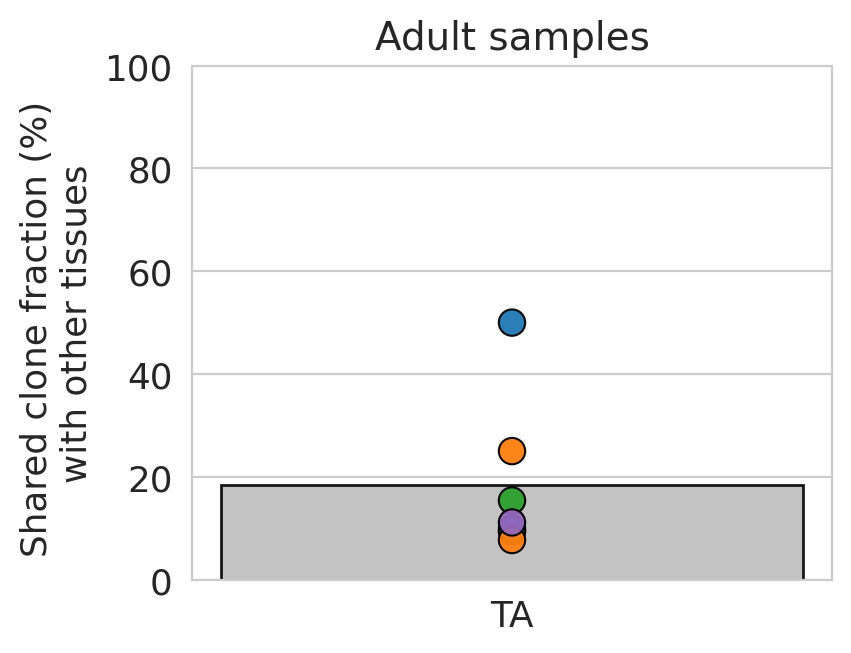

 Saved plot for Adult → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/figure/max_overlap_with_other_tissues_over_celltype_distinguish_ref_type_Adult.pdf


,celltype_id,overlap_fraction
0,0,18.330693



 Combined p-value summary:


,name,pvalue,variable


In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns
import cospar as cs
import numpy as np

# === Visualization settings ===
cs.settings.set_figure_params(figsize=(6, 5.5))
sns.set_style("whitegrid")

df_pvalue_list = []

# --- Define stage info manually for TA ---
df_final['stage'] = df_final.get('stage', 'TA')
title_map = {'TA': 'DARLIN TA Samples'}

# --- Basic tissue color map (extend automatically if needed) ---
if 'tissue_colors' not in globals():
    tissue_colors = dict(zip(
        ['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'Heart', 'Liver', 'SG-L1'],
        sns.color_palette("tab10", 7).as_hex()
    ))

for x in df_final['stage'].unique():
    print(f"\n=== Stage: {x} ===")

    # --- Filter relevant subset ---
    df_tmp = df_final[
        (df_final['stage'] == x)
        & (df_final['min_clone_size'] == min_clone_size)
        & (df_final['allele_complexity'] == 4)
        & (df_final['read_cutoff'] == read_cutoff)
    ].copy()

    if df_tmp.empty:
        print(f" Skipping {x}: no data after filtering.")
        continue

    print(f"  → Rows after filtering: {len(df_tmp)}")
    print(f"  → Unique tissues: {df_tmp['tissue'].unique()}")
    if 'target_cell_type' in df_tmp.columns:
        print(f"  → target_cell_type values: {df_tmp['target_cell_type'].unique()}")

    # --- Clean overlap_fraction ---
    df_tmp = df_tmp.dropna(subset=['overlap_fraction'])
    if df_tmp.empty:
        print(f"No valid overlap_fraction values for {x}. Skipping stage.")
        continue

    # --- Create 'celltype_id' if missing ---
    if 'celltype_id' not in df_tmp.columns:
        unique_types = (
            df_tmp['target_cell_type'].unique()
            if 'target_cell_type' in df_tmp.columns
            else ['TA']
        )
        df_tmp['target_cell_type'] = (
            df_tmp['target_cell_type'] if 'target_cell_type' in df_tmp.columns else 'TA'
        )
        df_tmp['celltype_id'] = df_tmp['target_cell_type'].astype('category').cat.codes
        print(f" Generated numeric IDs for {len(unique_types)} cell type(s): {unique_types}")

    # --- Extend tissue_colors if needed ---
    unique_tissues = sorted(df_tmp['tissue'].unique())
    missing = [t for t in unique_tissues if t not in tissue_colors]
    if missing:
        print(f" Adding missing tissue colors for: {missing}")
        extra_colors = sns.color_palette('tab10', len(missing)).as_hex()
        for t, c in zip(missing, extra_colors):
            tissue_colors[t] = c

    # --- Compute p-values across groups (optional) ---
    key_1 = 'target_cell_type'
    key_2 = 'overlap_fraction'
    if 'pvalue_estimation' in globals():
        try:
            df_pvalue_tmp = pvalue_estimation(df_tmp, key_1, key_2)
            df_pvalue_tmp['variable'] = x
            df_pvalue_list.append(df_pvalue_tmp)
        except Exception as e:
            print(f"p-value computation skipped for {x}: {e}")
    else:
        print("ℹ Skipping p-value estimation — function not defined in current session.")

    # --- Compute mean overlap for barplot ---
    df_tmp_1 = (
        df_tmp.groupby('celltype_id')[key_2]
        .mean()
        .reset_index()
        .sort_values('celltype_id')
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    kwargs = {'alpha': 0.9, 'linewidth': 1, 'edgecolor': 'k'}

    sns.barplot(
        data=df_tmp_1,
        x='celltype_id',
        y=key_2,
        color='#bdbdbd',
        ax=ax,
        **kwargs
    )

    sns.scatterplot(
        data=df_tmp,
        x=cs.pl.rand_jitter(df_tmp['celltype_id'], 0.03),
        y='overlap_fraction',
        hue='tissue',
        s=90,
        alpha=0.95,
        edgecolor='k',
        palette=tissue_colors,
        ax=ax
    )

    # --- Axis formatting ---
    xticks = sorted(df_tmp['celltype_id'].unique())
    xticklabels = sorted(df_tmp['target_cell_type'].unique())
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0)

    ax.get_legend().remove()
    plt.ylim([0, 100])
    ylabel = (
        'Shared clone fraction (%) \nwith other tissues'
        if len(unique_tissues) > 1
        else 'Shared clone fraction (%)'
    )
    plt.ylabel(ylabel)
    plt.xlabel('')

    plt.title(title_map.get(x, f'{x} samples'))
    plt.tight_layout()

    # --- Save ---
    out_file = f"{paper_figure_path}/max_overlap_with_other_tissues_over_celltype_{data_des}_{x}.pdf"
    plt.savefig(out_file)
    plt.show()
    print(f" Saved plot for {x} → {out_file}")

    display(df_tmp_1)

# --- Combine p-value summaries (if any) ---
if df_pvalue_list:
    df_pvalue = pd.concat(df_pvalue_list, ignore_index=True)
    print("\n Combined p-value summary:")
    display(df_pvalue)
else:
    print("\n No p-value data generated — likely only one target cell type (TA).")



=== Processing TA ===
📊 Avg target clone N for TA: 189.81
   Unique cell types: ['TA']
🎨 Adding missing cell type colors for: ['TA']


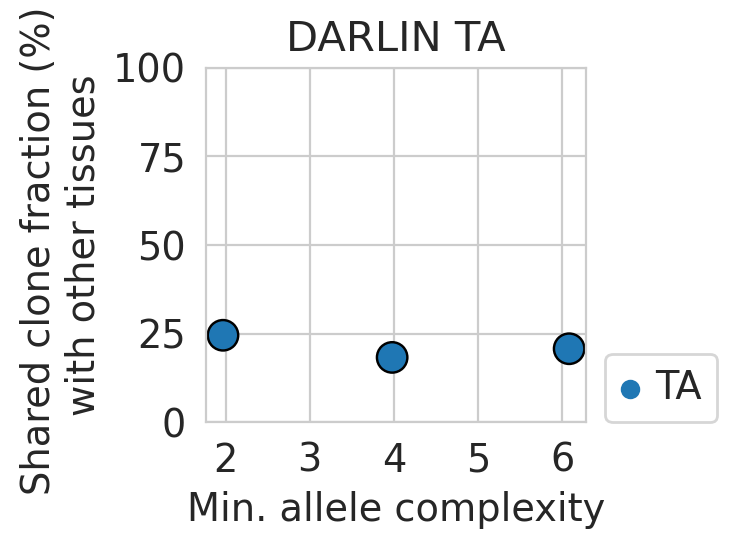

✅ Saved plot 1 → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/figure/max_overlap_with_other_tissues_over_mutation_num_distinguish_ref_type_TA.pdf


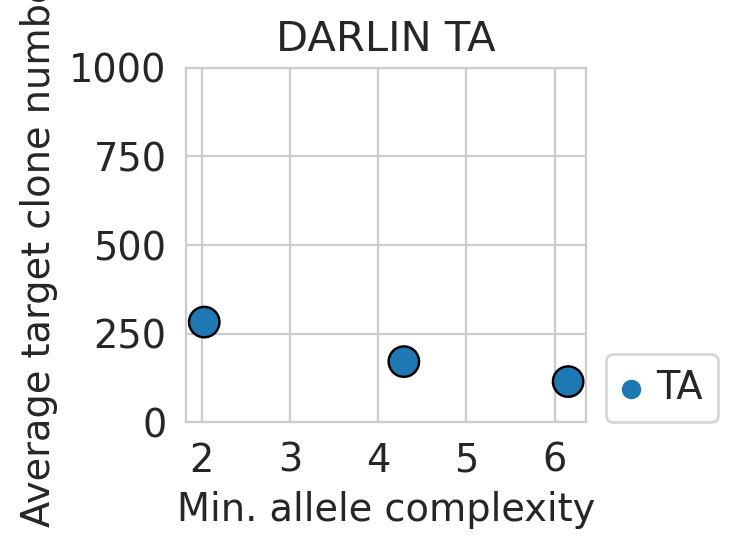

✅ Saved plot 2 → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/figure/target_clone_N_over_mutation_num_distinguish_ref_type_TA.pdf


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import cospar as cs

# === Visualization setup ===
cs.settings.set_figure_params(figsize=(6, 5.5), fontsize=15)
sns.set_style("whitegrid")

# === Define TA parameters ===
mouse_list = ['TA']
mouse_map_2 = {'TA': 'DARLIN TA'}
if 'celltype_colors' not in globals():
    celltype_colors = {'TA': '#ff7f0e'}  # orange tone for TA samples

for mouse in mouse_list:
    print(f"\n=== Processing {mouse} ===")

    # --- Filter data for this mouse ---
    df_tmp = df_final[
        (df_final['allele_complexity'] <= 6)
        & (df_final['mouse'] == mouse)
        & (df_final['min_clone_size'] == min_clone_size)
        & (df_final['read_cutoff'] == read_cutoff)
    ].copy()

    if df_tmp.empty:
        print(f" No data available for {mouse}, skipping.")
        continue

    # --- Ensure required columns exist ---
    if 'target_cell_type' not in df_tmp.columns or df_tmp['target_cell_type'].nunique() == 0:
        df_tmp['target_cell_type'] = 'TA'

    if 'target_clone_N' not in df_tmp.columns:
        df_tmp['target_clone_N'] = 0  # placeholder if not computed upstream

    # --- Compute mean per allele complexity × cell type ---
    df_tmp = (
        df_tmp.groupby(['allele_complexity', 'target_cell_type'])
        .mean(numeric_only=True)
        .reset_index()
    )

    avg_target = df_tmp['target_clone_N'].mean()
    print(f" Avg target clone N for {mouse}: {avg_target:.2f}")
    print(f"   Unique cell types: {df_tmp['target_cell_type'].unique()}")

    # --- Extend color palette if needed ---
    unique_types = sorted(df_tmp['target_cell_type'].unique())
    missing = [t for t in unique_types if t not in celltype_colors]
    if missing:
        print(f" Adding missing cell type colors for: {missing}")
        extra_colors = sns.color_palette('tab10', len(missing)).as_hex()
        for t, c in zip(missing, extra_colors):
            celltype_colors[t] = c

    # ============================================================
    #   Plot 1: Shared clone fraction (%)
    # ============================================================
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.scatterplot(
        data=df_tmp,
        x=cs.pl.rand_jitter(df_tmp['allele_complexity'], 0.05),
        y='overlap_fraction',
        hue='target_cell_type',
        s=120,
        alpha=1,
        edgecolor='k',
        palette=celltype_colors,
        ax=ax
    )

    ax.get_legend().remove()
    plt.legend(loc=[1.05, 0])
    plt.ylim([0, 100])
    plt.xticks([2, 3, 4, 5, 6], [2, 3, 4, 5, 6])
    plt.ylabel('Shared clone fraction (%) \nwith other tissues')
    plt.xlabel('Min. allele complexity')
    plt.title(mouse_map_2.get(mouse, mouse))
    plt.tight_layout()

    out_path1 = f"{paper_figure_path}/max_overlap_with_other_tissues_over_mutation_num_{data_des}_{mouse}.pdf"
    plt.savefig(out_path1)
    plt.show()
    print(f" Saved plot 1 → {out_path1}")

    # ============================================================
    #   Plot 2: Average target clone number
    # ============================================================
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.scatterplot(
        data=df_tmp,
        x=cs.pl.rand_jitter(df_tmp['allele_complexity'], 0.05),
        y='target_clone_N',
        hue='target_cell_type',
        s=120,
        alpha=1,
        edgecolor='k',
        palette=celltype_colors,
        ax=ax
    )

    ax.get_legend().remove()
    plt.legend(loc=[1.05, 0])
    plt.xticks([2, 3, 4, 5, 6], [2, 3, 4, 5, 6])

    # Dynamic y-limit
    if 'ylim_map' in globals() and mouse in ylim_map:
        plt.ylim([0, ylim_map[mouse]])
    else:
        plt.ylim([0, df_tmp['target_clone_N'].max() * 1.1])

    plt.ylabel('Average target clone number')
    plt.xlabel('Min. allele complexity')
    plt.title(mouse_map_2.get(mouse, mouse))
    plt.tight_layout()

    out_path2 = f"{paper_figure_path}/target_clone_N_over_mutation_num_{data_des}_{mouse}.pdf"
    plt.savefig(out_path2)
    plt.show()
    print(f" Saved plot 2 → {out_path2}")

    plt.close('all')



=== Processing TA ===
  → 1 rows aggregated by read_cutoff and target_cell_type.
Saved → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/figure/max_overlap_with_other_tissues_over_readcutoff_distinguish_ref_type_Adult.pdf


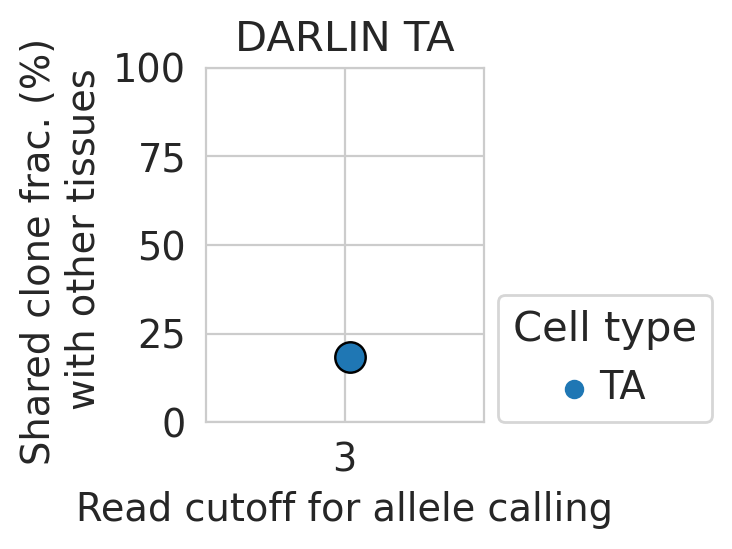

In [71]:
# ============================================================
#   Shared clone fraction vs. read cutoff across cell types (TA dataset)
# ============================================================

data_des = 'distinguish_ref_type'

for mouse in mouse_list:
    print(f"\n=== Processing {mouse} ===")

    # --- Filter relevant subset ---
    df_tmp = df_final[
        (df_final['min_clone_size'] == min_clone_size)
        & (df_final['mouse'] == mouse)
        & (df_final['allele_complexity'] == 4)
    ].copy()

    if df_tmp.empty:
        print(f"Warning: No data found for {mouse}, skipping.")
        continue

    # --- Ensure 'target_cell_type' exists ---
    if 'target_cell_type' not in df_tmp.columns or df_tmp['target_cell_type'].nunique() == 0:
        df_tmp['target_cell_type'] = 'TA'

    # --- Compute means ---
    key_1 = 'read_cutoff'
    key_2 = 'overlap_fraction'
    df_tmp = (
        df_tmp.groupby([key_1, 'target_cell_type'])
        .mean(numeric_only=True)
        .reset_index()
    )

    print(f"  → {len(df_tmp)} rows aggregated by {key_1} and target_cell_type.")

    # --- Extend color palette dynamically ---
    unique_types = sorted(df_tmp['target_cell_type'].unique())
    missing = [t for t in unique_types if t not in celltype_colors]
    if missing:
        print(f"Adding missing colors for: {missing}")
        extra_colors = sns.color_palette('tab10', len(missing)).as_hex()
        for t, c in zip(missing, extra_colors):
            celltype_colors[t] = c

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.scatterplot(
        data=df_tmp,
        x=cs.pl.rand_jitter(df_tmp[key_1], 0.05),
        y=key_2,
        hue='target_cell_type',
        s=120,
        alpha=1,
        edgecolor='k',
        palette=celltype_colors,
        ax=ax
    )

    plt.legend(loc=[1.05, 0], title='Cell type')
    plt.ylim([0, 100])

    # dynamic xticks based on unique read_cutoff values
    xticks_sorted = sorted(df_tmp[key_1].unique())
    ax.set_xticks(xticks_sorted)
    ax.set_xticklabels([str(int(x)) for x in xticks_sorted], rotation=0)
    ax.set_xlim([min(xticks_sorted) - 0.5, max(xticks_sorted) + 0.5])

    plt.ylabel('Shared clone frac. (%) \n with other tissues')
    plt.xlabel('Read cutoff for allele calling')

    # Safe title mapping
    plt.title(mouse_map_2.get(mouse, mouse))
    plt.tight_layout()

    # Save + show
    out_path = f"{paper_figure_path}/max_overlap_with_other_tissues_over_readcutoff_{data_des}_{mouse_map.get(mouse, mouse)}.pdf"
    plt.savefig(out_path)
    print(f"Saved → {out_path}")

    plt.show()
    plt.close()


In [72]:
print(upset.intersections)


DRG-R2  DRG-R1  SG-L1  Liver-TA_  DRG-L2  DRG-L1
True    False   False  False      False   False     697
False   True    False  False      False   False     458
        False   True   False      False   False     408
                False  True       False   False     162
                       False      True    False      41
                                  False   True       21
True    True    False  False      False   False      17
        False   True   False      False   False       7
False   True    True   False      False   False       8
True    False   False  True       False   False       1
False   False   True   True       False   False       1
True    False   False  False      True    False       1
                                  False   True        1
        True    True   False      False   False       3
False   True    False  True       True    False       1
Name: ones, dtype: int64


Building tissue × clone matrix for TA (Heart removed) ...
Binary matrix shape: (2596, 6)
Included tissues: ['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'Liver-TA_', 'SG-L1']
Total unique clones: 1827


<Figure size 800x500 with 0 Axes>

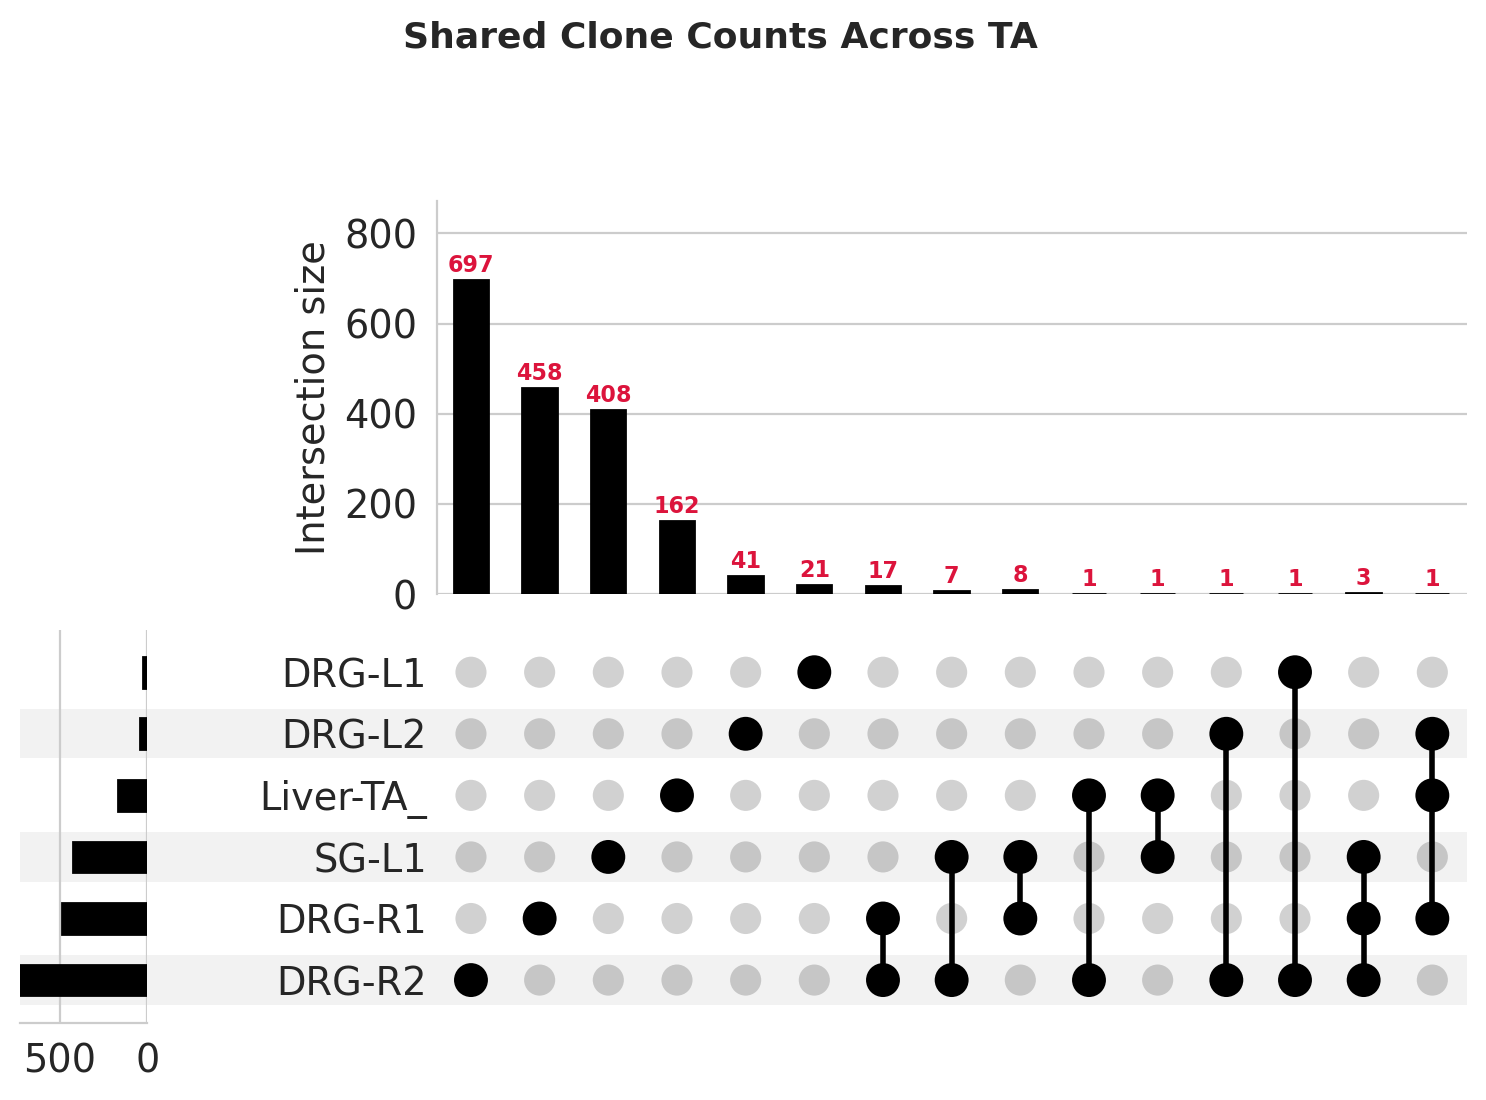

UpSet plot saved → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/figure/Shared_Clone_Counts_UpSet_TA_noHeart.pdf


In [76]:
# ============================================================
#   UpSet plot of shared clone counts across TA tissues
#   (Heart removed)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

# === Step 1: Build binary clone × tissue matrix ===
# Exclude Heart-TA samples explicitly
#excluded_tissues = ['Heart-TA_']   # remove Heart

# Ensure df_clone_HQ_grouped exists
# Columns expected: ['tissue', 'allele', 'count']

print("Building tissue × clone matrix for TA (Heart removed) ...")
df_table = (
    df_clone_HQ_grouped
    .pivot(index='allele', columns='tissue', values='count')
    .fillna(0)
)

# Drop Heart (and any others in excluded_tissues)
df_table = df_table.drop(columns=excluded_tissues, errors='ignore')

# Convert to binary presence/absence
df_binary = (df_table > 0).astype(int)
print(f"Binary matrix shape: {df_binary.shape}")
print(f"Included tissues: {list(df_binary.columns)}")

# === Step 2: Build membership list for each allele ===
allele_to_samples = (
    df_binary[df_binary == 1]
    .stack()
    .reset_index()
    .groupby('allele')['tissue']
    .apply(list)
)
memberships = allele_to_samples.tolist()
print(f"Total unique clones: {len(memberships)}")

# === Step 3: Generate intersection data ===
data_upset = from_memberships(memberships)
data_upset = data_upset.groupby(level=list(range(data_upset.index.nlevels))).size()

# === Step 4: Plot annotated UpSet ===
plt.figure(figsize=(8, 5))
upset = UpSet(
    data_upset,
    sort_by='degree',
    show_counts=False,
    facecolor='black',
)

axes_dict = upset.plot()
ax = axes_dict.get('intersections', plt.gca())

# === Step 5: Add aligned count labels ===
bars = ax.patches
vals = list(upset.intersections)

for patch, val in zip(bars, vals):
    if val > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + (0.01 * data_upset.max()),
            f"{int(val)}",
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold',
            color='crimson'
        )

# === Step 6: Adjust and polish ===
ax.set_ylim(0, data_upset.max() * 1.25)  # add padding

plt.suptitle(
    'Shared Clone Counts Across TA',
    y=1.05,
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()

# === Step 7: Save and show ===
out_path = f"{paper_figure_path}/Shared_Clone_Counts_UpSet_TA_noHeart.pdf"
plt.savefig(out_path, format='pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"UpSet plot saved → {out_path}")


Building tissue × clone matrix for TA (Heart included) ...
Binary matrix shape: (2596, 7)
Included tissues: ['DRG-L1', 'DRG-L2', 'DRG-R1', 'DRG-R2', 'Heart-TA_', 'Liver-TA_', 'SG-L1']
Total unique clones: 2596


<Figure size 800x500 with 0 Axes>

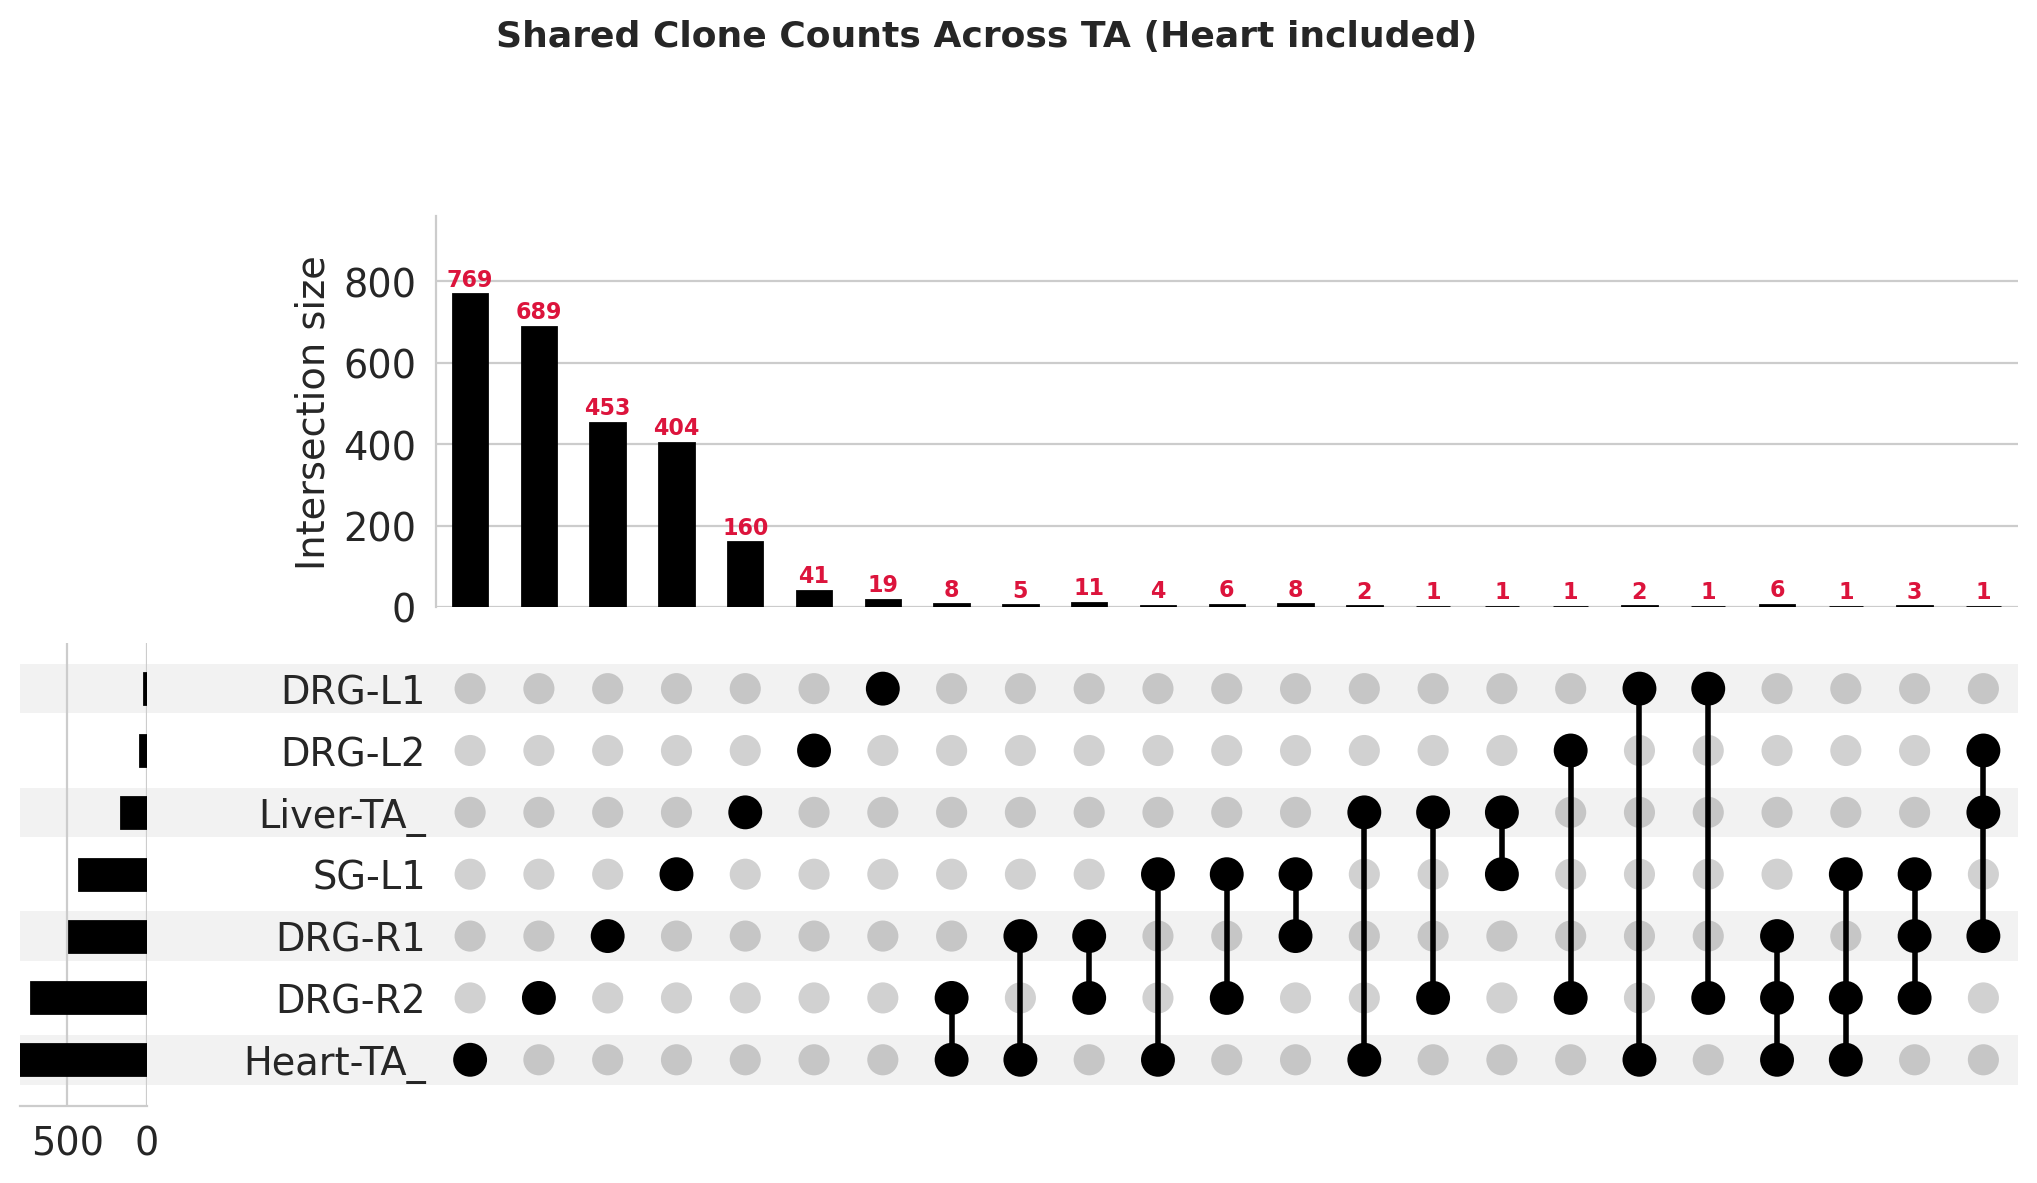

UpSet plot saved → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/TA/DARLIN/results_cutoff_override_3/figure/Shared_Clone_Counts_UpSet_TA.pdf


In [77]:
# ============================================================
#   UpSet plot of shared clone counts across TA tissues
#   (Heart included)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

# === Step 1: Build binary clone × tissue matrix ===
# (Heart included — no exclusions)
# Columns expected: ['tissue', 'allele', 'count']

print("Building tissue × clone matrix for TA (Heart included) ...")

df_table = (
    df_clone_HQ_grouped
    .pivot(index='allele', columns='tissue', values='count')
    .fillna(0)
)

# Convert to binary presence/absence
df_binary = (df_table > 0).astype(int)
print(f"Binary matrix shape: {df_binary.shape}")
print(f"Included tissues: {list(df_binary.columns)}")

# === Step 2: Build membership list for each allele ===
allele_to_samples = (
    df_binary[df_binary == 1]
    .stack()
    .reset_index()
    .groupby('allele')['tissue']
    .apply(list)
)

memberships = allele_to_samples.tolist()
print(f"Total unique clones: {len(memberships)}")

# === Step 3: Generate intersection data ===
data_upset = from_memberships(memberships)
data_upset = data_upset.groupby(level=list(range(data_upset.index.nlevels))).size()

# === Step 4: Plot annotated UpSet ===
plt.figure(figsize=(8, 5))
upset = UpSet(
    data_upset,
    sort_by='degree',
    show_counts=False,
    facecolor='black',
)

axes_dict = upset.plot()
ax = axes_dict.get('intersections', plt.gca())

# === Step 5: Add aligned count labels ===
bars = ax.patches
vals = list(upset.intersections)

for patch, val in zip(bars, vals):
    if val > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + (0.01 * data_upset.max()),
            f"{int(val)}",
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold',
            color='crimson'
        )

# === Step 6: Adjust and polish ===
ax.set_ylim(0, data_upset.max() * 1.25)

plt.suptitle(
    'Shared Clone Counts Across TA (Heart included)',
    y=1.05,
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()

# === Step 7: Save and show ===
out_path = f"{paper_figure_path}/Shared_Clone_Counts_UpSet_TA.pdf"
plt.savefig(out_path, format='pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"UpSet plot saved → {out_path}")
